<a href="https://colab.research.google.com/github/OJB-Quantum/QC-Hardware-How-To/blob/main/Jupyter%20Notebook%20Scripts/Parametric_Amplification_Plot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

### This notebook starts with some simple plots to visualize amplification typically performed by superconducting, quantum-limited parametric amplifiers. It then progresses to simulation plots for a slightly more realistic output.

The exploration of superconducting quantum devices demands precise numerical simulations to visualize wave propagation dynamics because the fundamental operational mechanism relies inherently upon the nondissipative nonlinearity originating from the Josephson junction (JJ). The macroscopic quantum behavior of this discrete superconducting weak link produces a purely dispersive response, which is governed by the standard Josephson relations for the supercurrent $I$ and the voltage $V$, explicitly given by $I = I_c \sin(\varphi)$ and $V = \frac{\Phi_0}{2\pi} \frac{d\varphi}{dt}$, where $I_c$ represents the critical current, $\Phi_0$ denotes the magnetic flux quantum, and $\varphi$ signifies the superconducting phase difference across the junction. Taking the temporal derivative of the supercurrent reveals a phase dependent dynamic inductance defined by $L_J(\varphi) = \frac{\Phi_0}{2\pi I_c \cos(\varphi)}$. Expanding this inductive term via a Taylor series generates the essential higher order electrical nonlinearities that mediate continuous energy exchange among interacting propagating modes or localized cavity resonances. Utilizing this physical mechanism, a Josephson Traveling Wave Parametric Amplifier (JTWPA) facilitates the spatial mixing of microwaves along a transmission line, transferring energy from a high power pump wave to a weaker signal wave while concurrently generating an idler wave. The continuous spatial evolution of these complex wave amplitudes is modeled through Coupled Mode Theory (CMT), employing Ordinary Differential Equations (ODEs) across the spatial propagation distance $z$. The primary variables include the complex slowly varying signal amplitude $A_s(z)$, the complex slowly varying idler amplitude $A_i(z)$, the parametric coupling strength $\kappa$, and the phase mismatch $\Delta k$. Conversely, a Josephson Parametric Amplifier (JPA) operates as a localized resonant cavity, which is mathematically represented in the time domain $t$ as a driven, damped harmonic oscillator featuring a modulated kinetic inductance. The governing parameters for the localized cavity include the resonant angular frequency $\omega_0$, the dissipative damping rate $\gamma$, and the fractional modulation depth $\lambda$.

The governing coupled mode equations for the spatial envelope evolution are formulated below.

$$ \frac{dA_s(z)}{dz} = i \kappa A_i^*(z) e^{-i \Delta k z} $$

$$ \frac{dA_i^*(z)}{dz} = -i \kappa A_s(z) e^{i \Delta k z} $$

The parametric amplification of the intracavity flux $\Phi(t)$ relies on the following classical Mathieu equation.

$$ \frac{d^2\Phi(t)}{dt^2} + \gamma \frac{d\Phi(t)}{dt} + \omega_0^2 (1 + \lambda \cos(2\omega_0 t)) \Phi(t) = 0 $$

In summary, the foundational nonlinearity of the Josephson junction dynamic inductance provides the essential wave mixing physical basis required to accurately parameterize both the spatial signal growth and the temporal resonant cavity modulation.

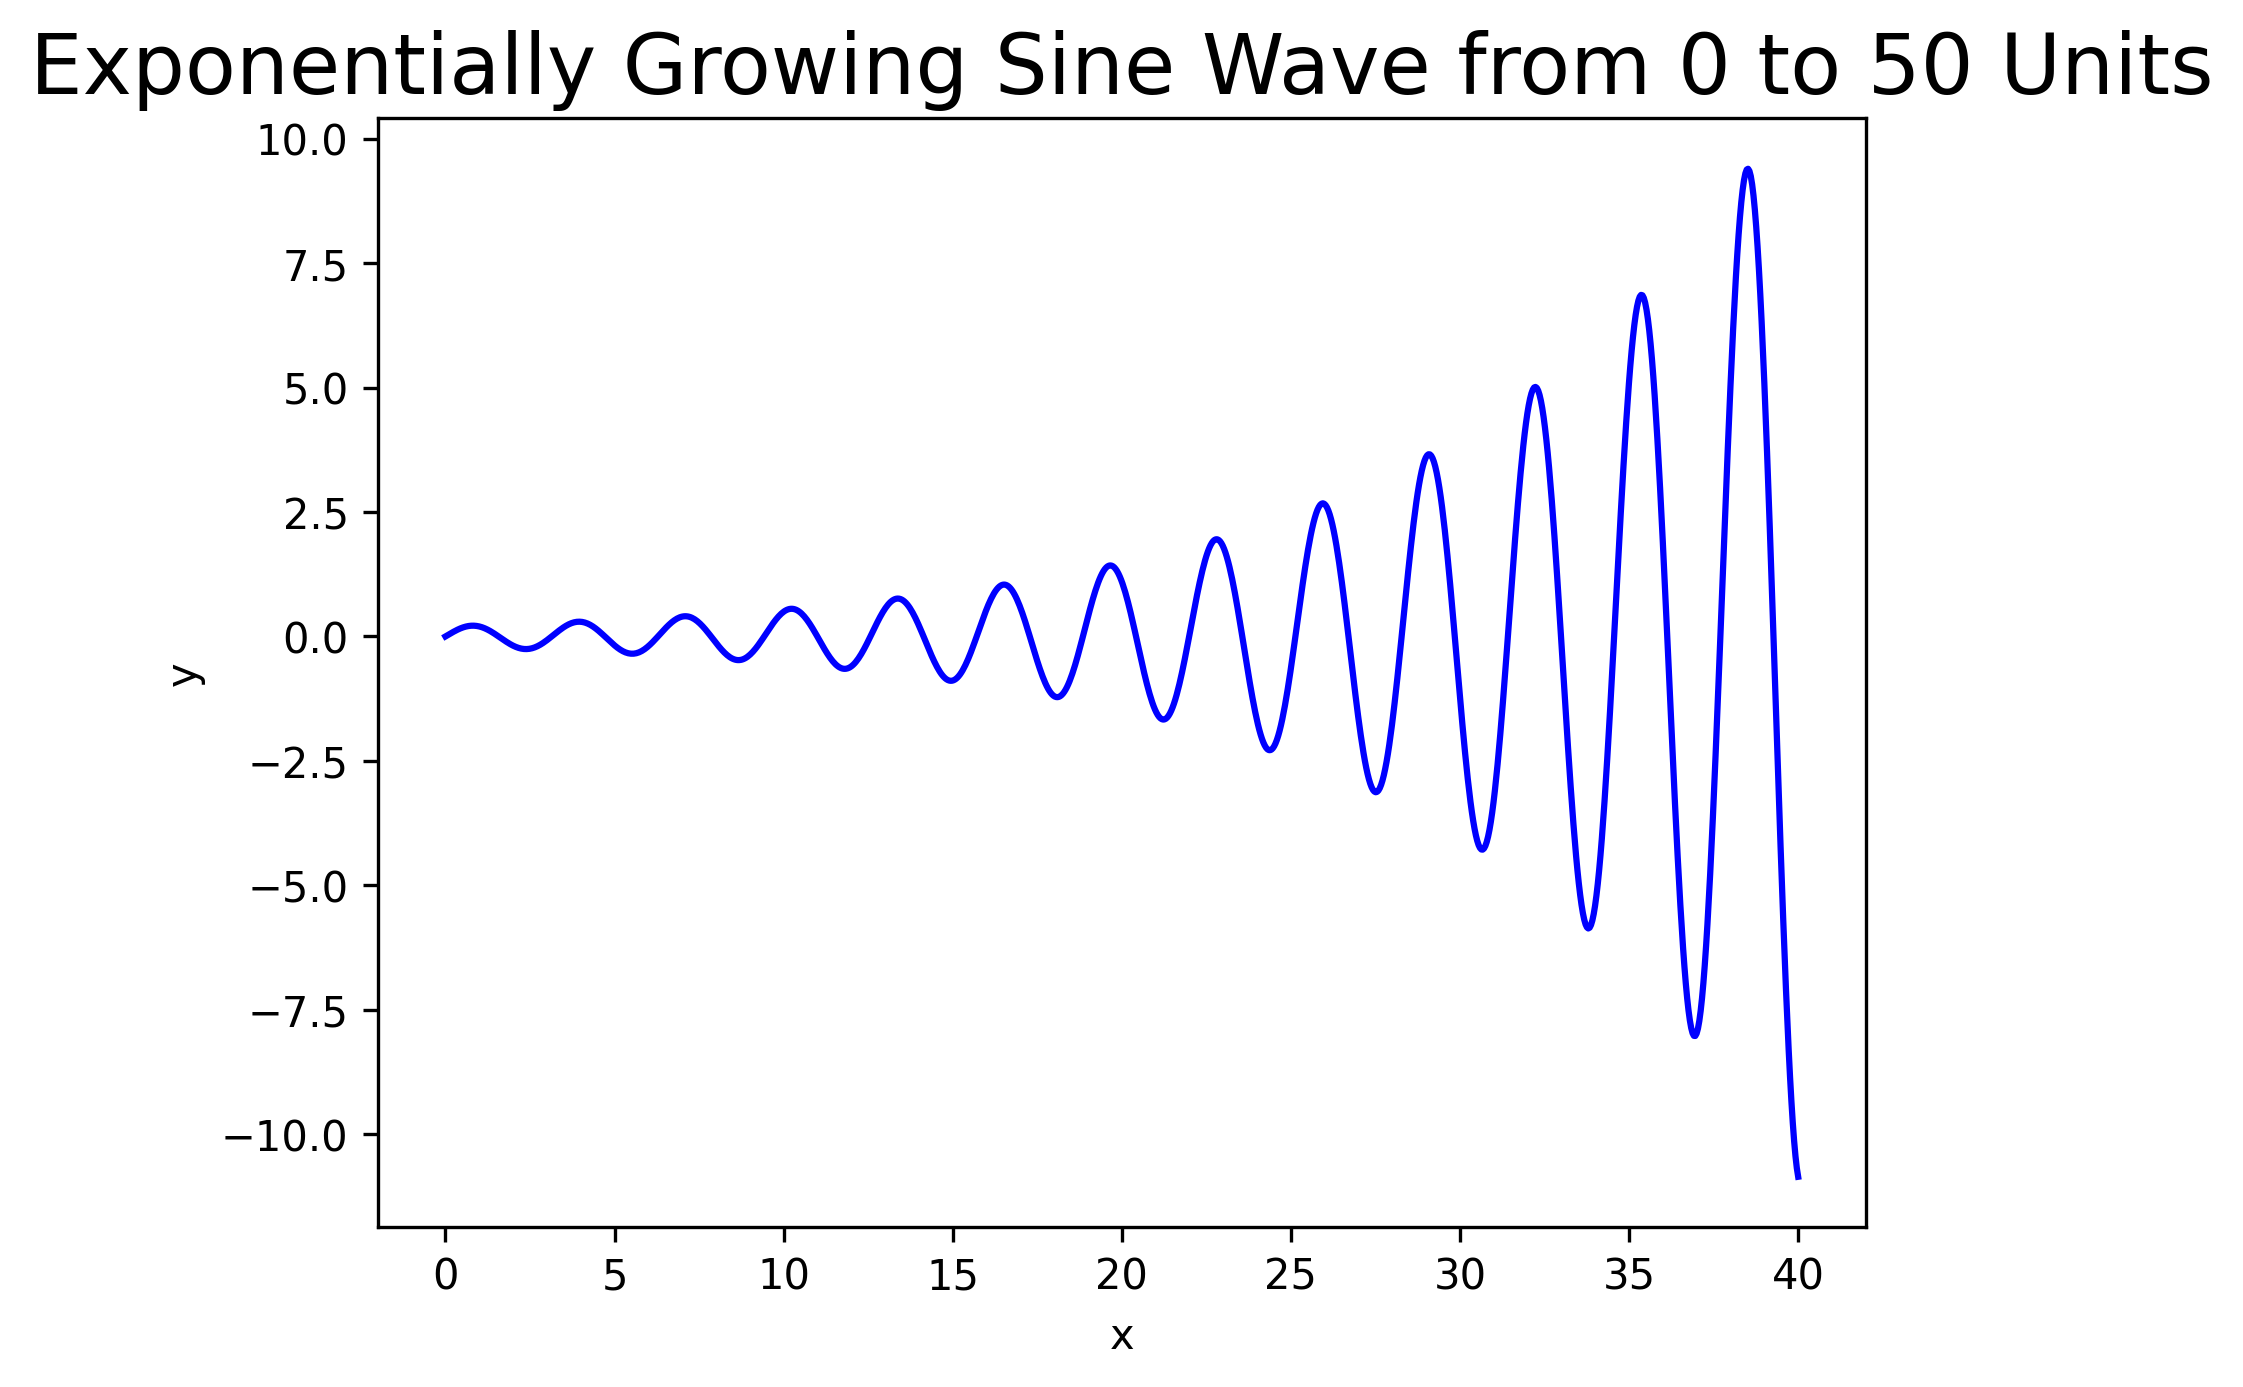

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Set high DPI via rcParams
plt.rcParams['figure.dpi'] = 300

# Generate data
x = np.linspace(0, 40, 1000)            # Range from 0 to 50
amplitude = 0.2 * np.exp(0.1 * x)       # Start at 0.2 and grow exponentially
y = amplitude * np.sin(2 * x)

# Create figure and plot
plt.figure()
plt.plot(x, y, color='blue', label='Exponentially Growing Sine (0.2 initial)')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Exponentially Growing Sine Wave from 0 to 50 Units')

# Remove grid lines
plt.grid(False)

# Optional: show legend
# plt.legend()

# Display the plot
plt.show()


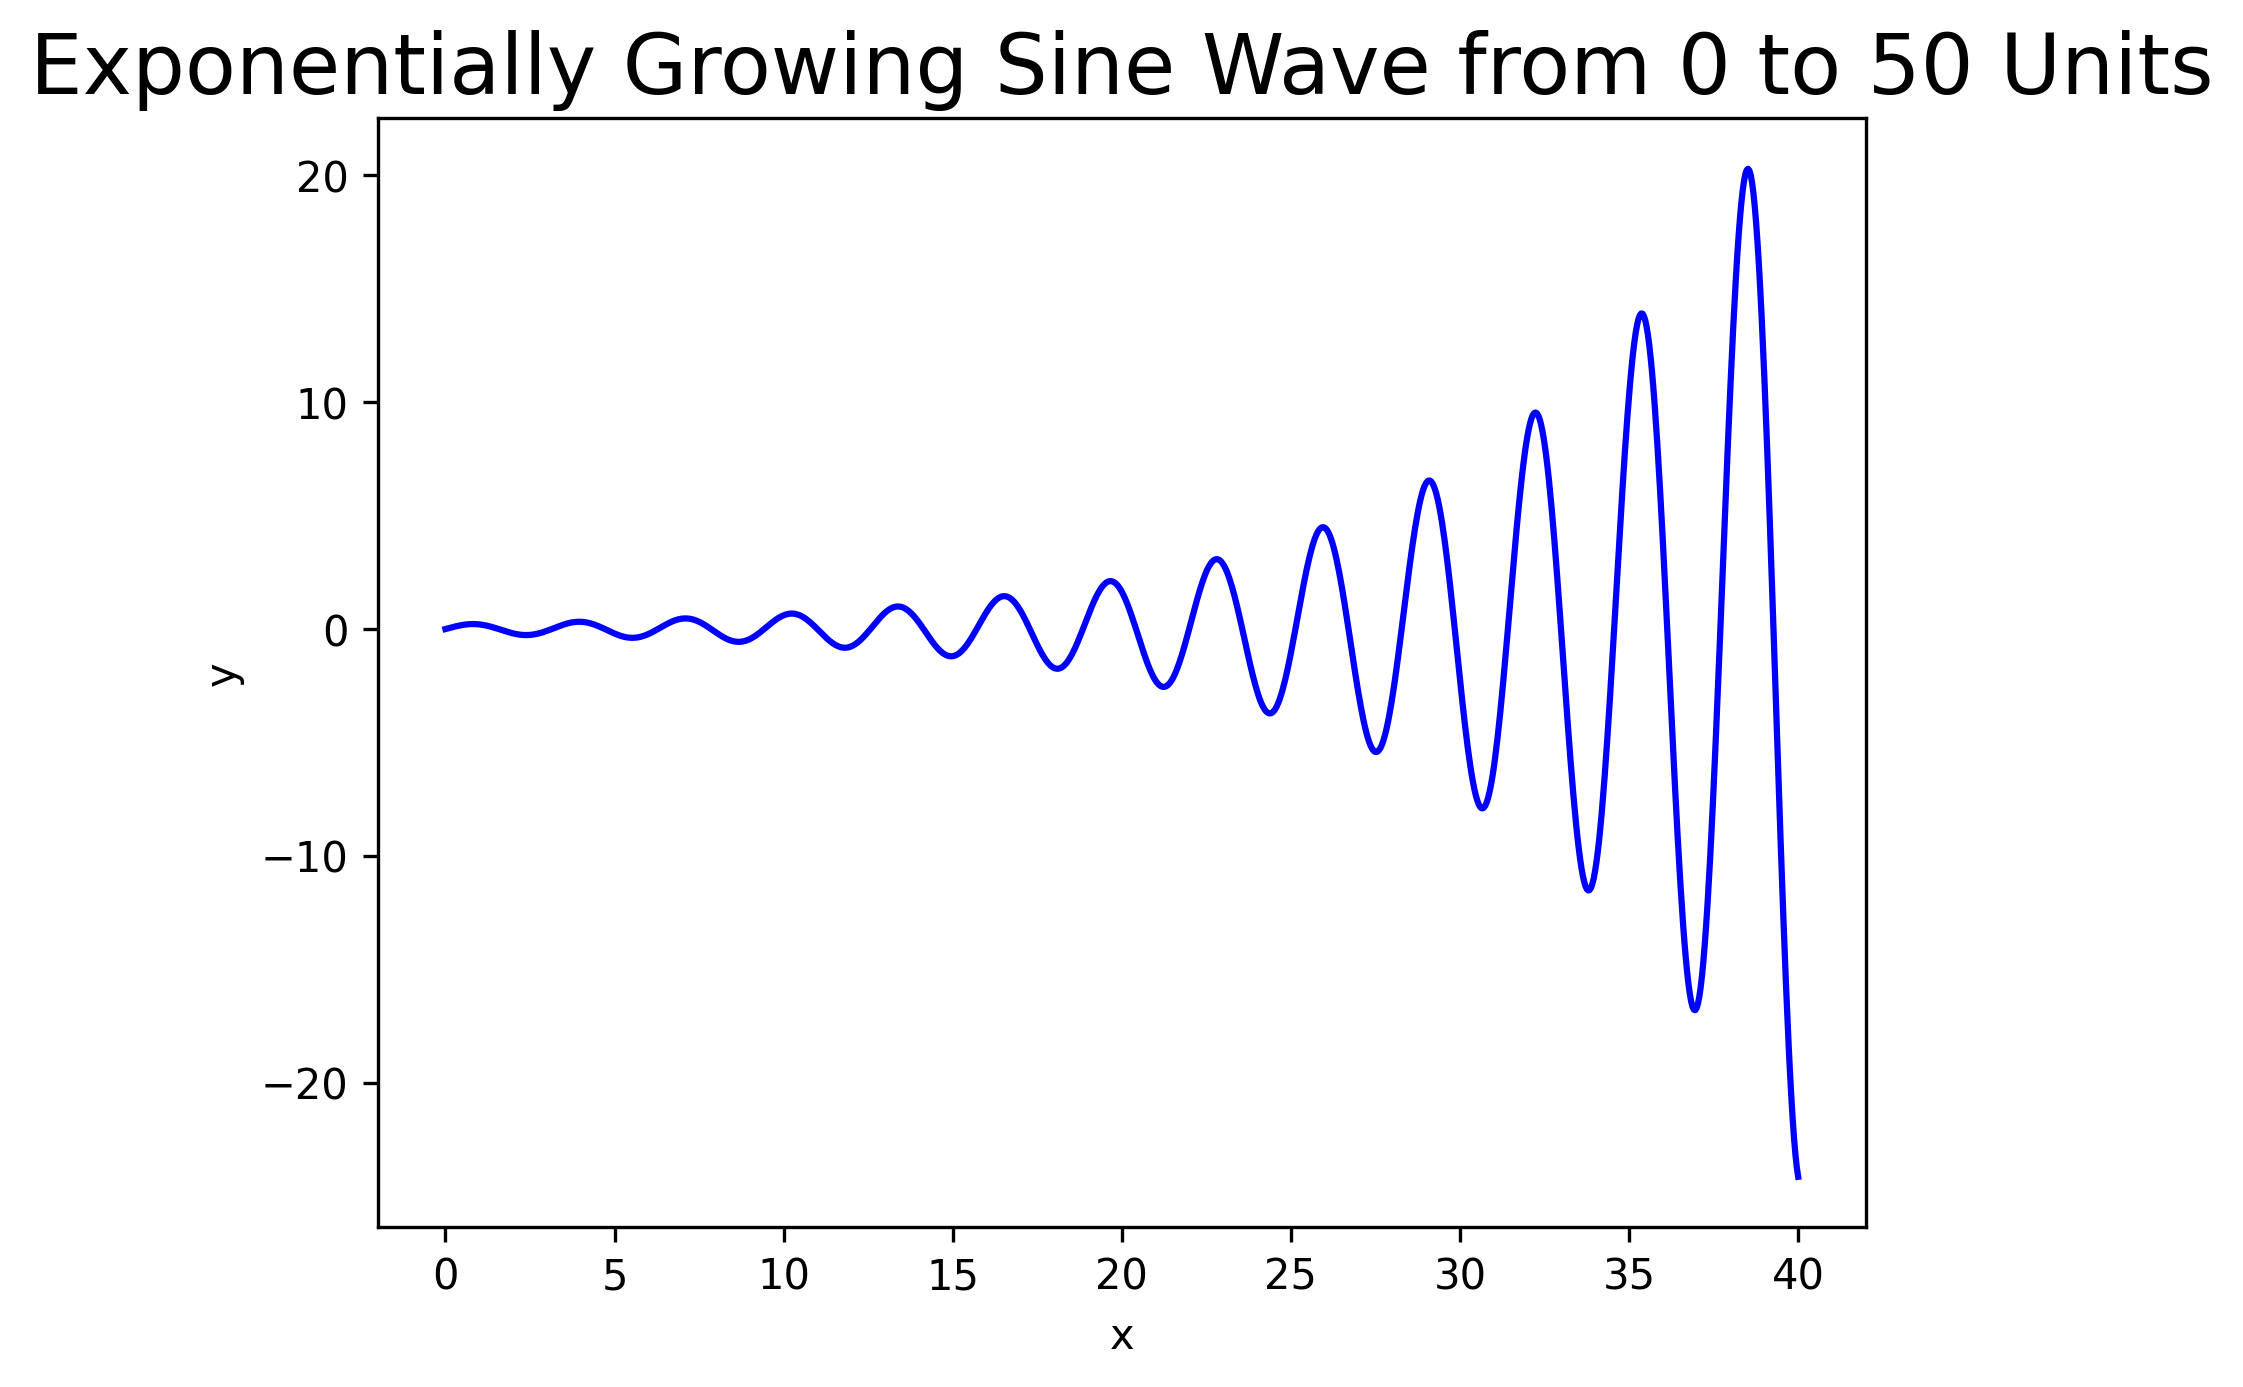

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Set high DPI via rcParams
plt.rcParams['figure.dpi'] = 300

# Generate data
x = np.linspace(0, 40, 1000)            # Range from 0 to 50
amplitude = 0.2 * np.exp(0.12 * x)       # Start at 0.2 and grow exponentially at a different rate
y = amplitude * np.sin(2 * x)

# Create figure and plot
plt.figure()
plt.plot(x, y, color='blue', label='Exponentially Growing Sine (0.2 initial)')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Exponentially Growing Sine Wave from 0 to 50 Units')

# Remove grid lines
plt.grid(False)

# Optional: show legend
# plt.legend()

# Display the plot
plt.show()

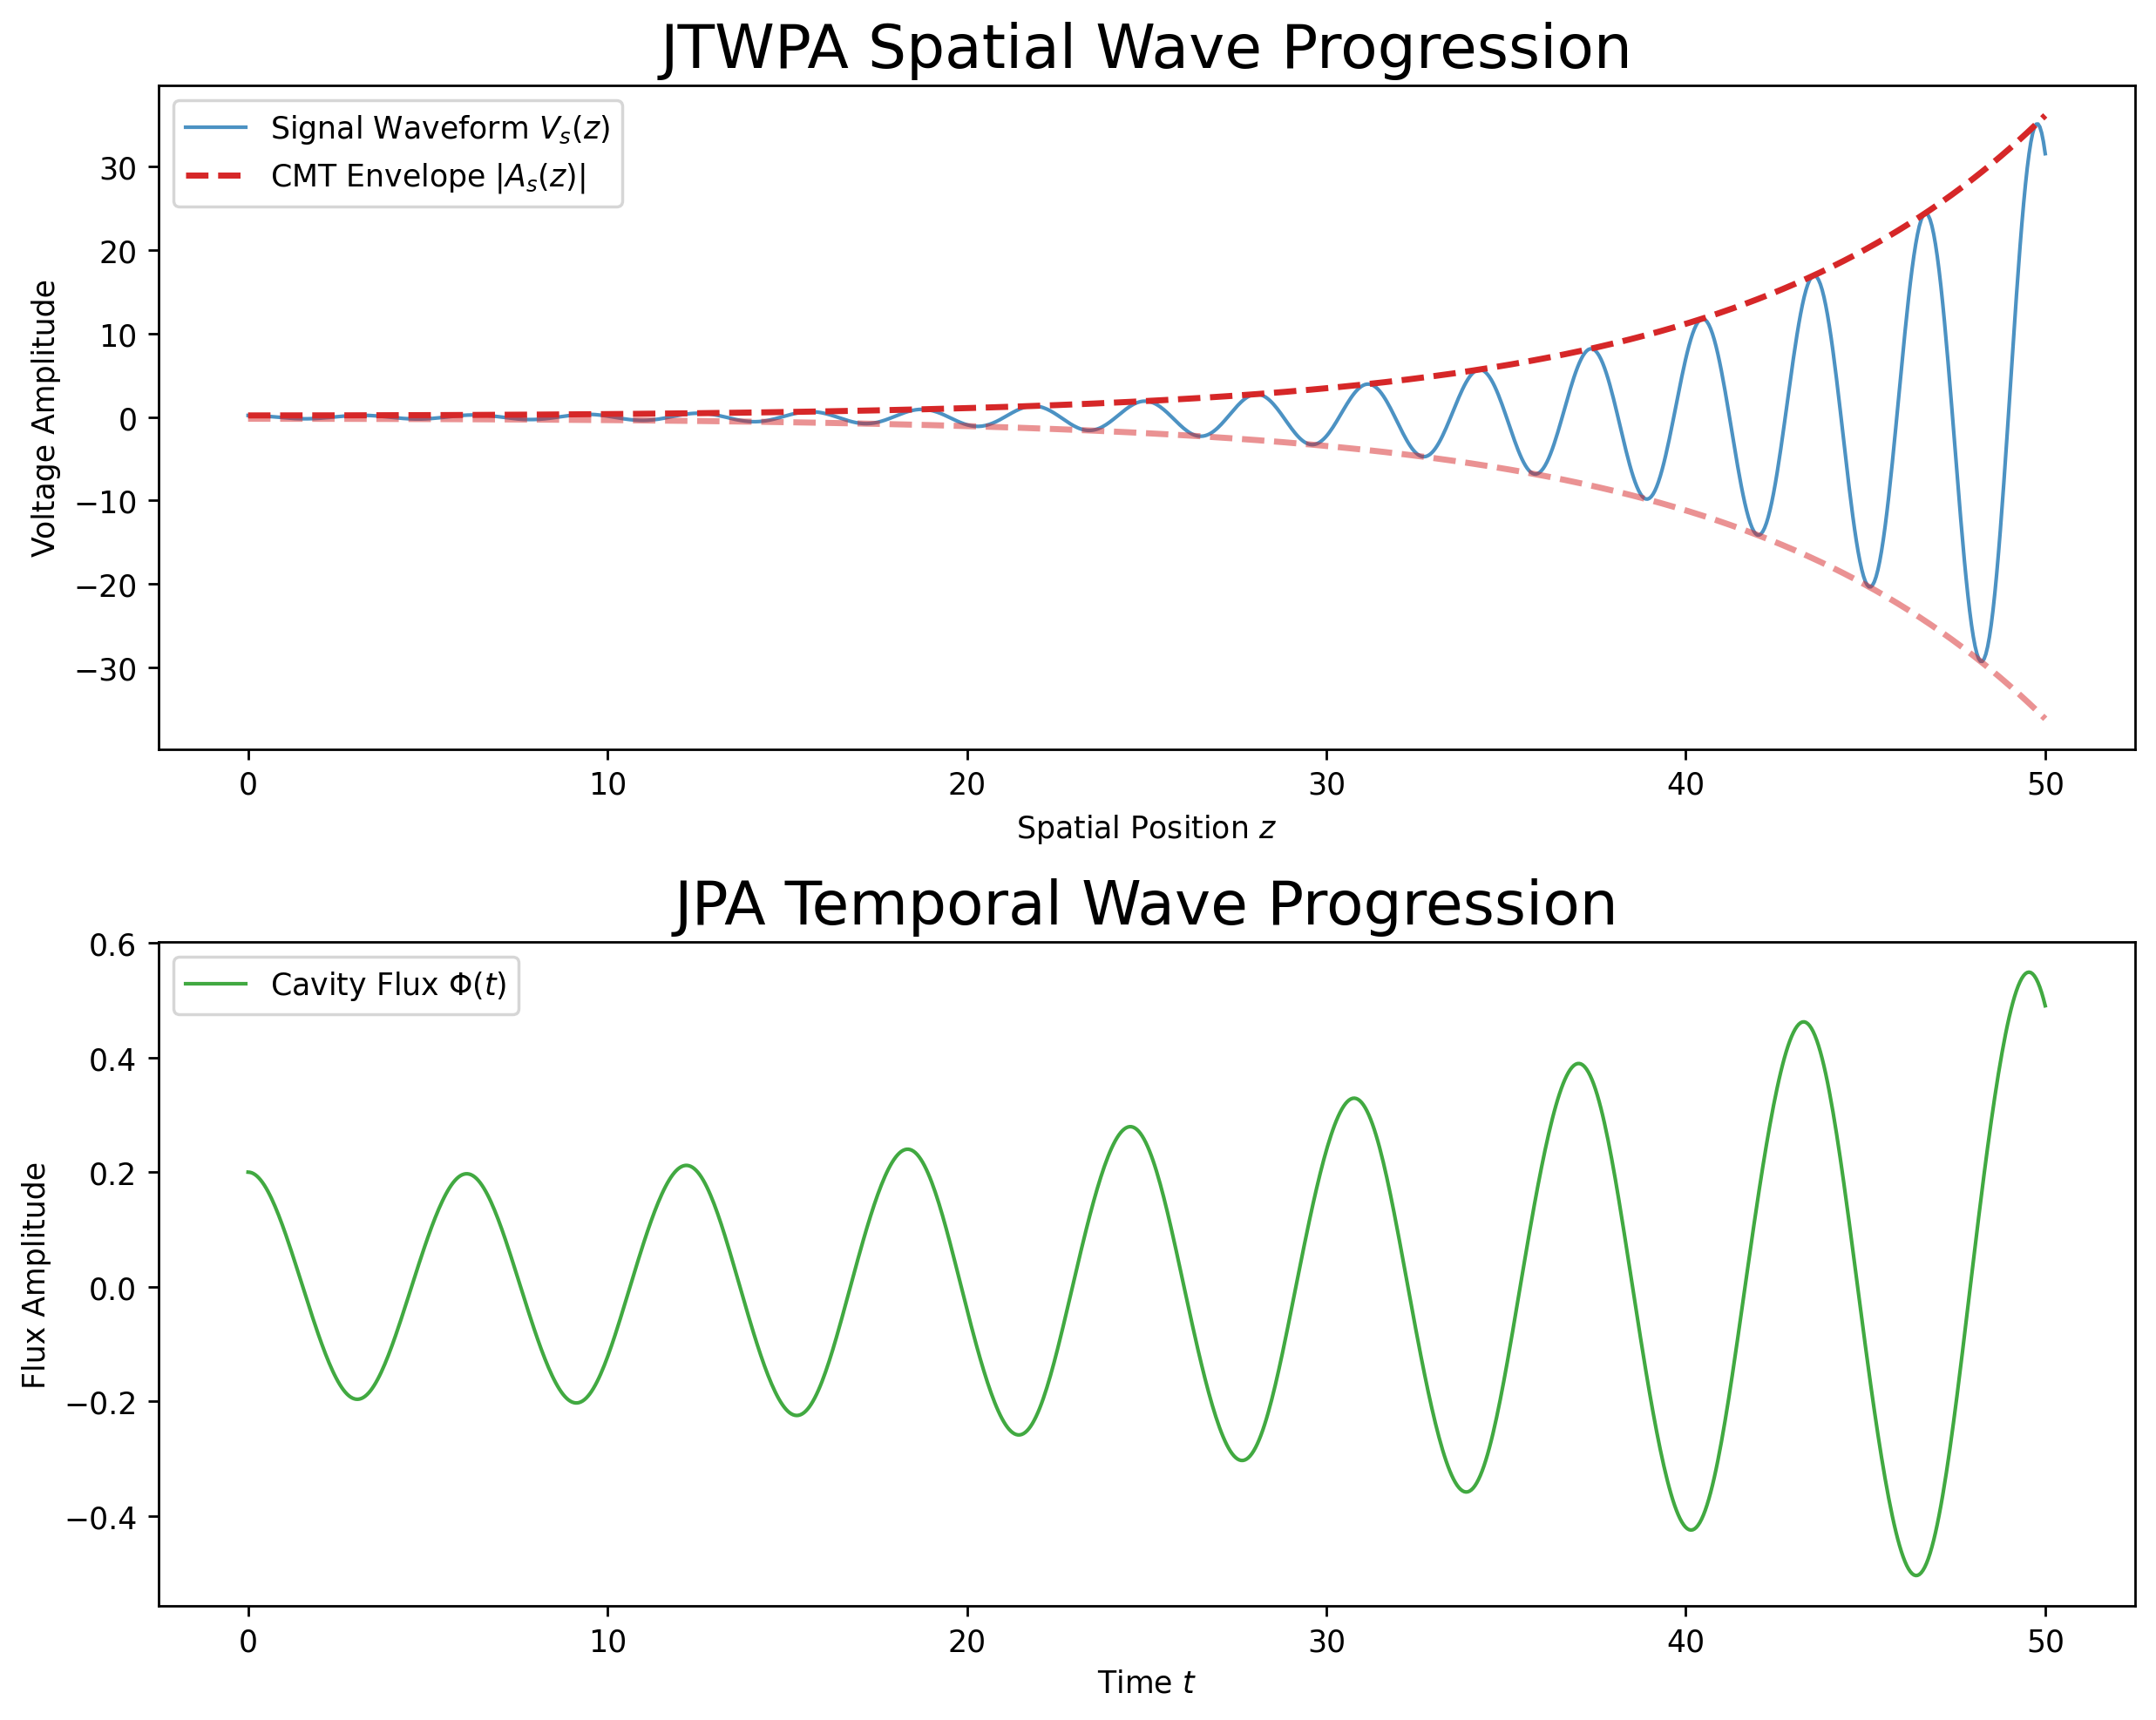

In [4]:
# Installation of necessary libraries via pip or uv
# pip install numpy scipy matplotlib
# uv pip install numpy scipy matplotlib

"""
Simulation and visualization of superconducting parametric amplifiers.

This module numerically integrates the Coupled Mode Theory (CMT) spatial
equations for a Josephson Traveling Wave Parametric Amplifier (JTWPA)
and the temporal Mathieu equation for a Josephson Parametric Amplifier (JPA).
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# =============================================================================
# CONTROL KNOBS AND PARAMETERS
# =============================================================================
# JTWPA (Spatial Domain) Parameters
JTWPA_LENGTH = 50.0          # Total length of the transmission line
JTWPA_KAPPA = 0.12           # Parametric coupling strength
JTWPA_DELTA_K = 0.05         # Phase mismatch
JTWPA_SIGNAL_INIT = 0.2      # Initial signal amplitude
JTWPA_IDLER_INIT = 0.0       # Initial idler amplitude
JTWPA_WAVE_VECTOR = 2.0      # Spatial frequency for visualization

# JPA (Temporal Domain) Parameters
JPA_DURATION = 50.0          # Total duration of the pump pulse
JPA_OMEGA_0 = 1.0            # Cavity resonant frequency
JPA_GAMMA = 0.02             # Cavity damping rate
JPA_LAMBDA = 0.15            # Parametric modulation depth
JPA_PHI_INIT = 0.2           # Initial flux amplitude
JPA_PHIDOT_INIT = 0.0        # Initial flux derivative

# Matplotlib High-Resolution and Typography Settings
plt.rcParams.update({
    'figure.dpi': 250,
    'font.sans-serif': ['Tahoma', 'DejaVu Sans'],
    'font.weight': 'normal',
    'axes.titleweight': 'normal',
    'axes.titlesize': 20
})

# =============================================================================
# JTWPA MODEL SPATIAL COUPLED MODE THEORY ODEs
# =============================================================================
def compute_jtwpa_derivatives(z, y, kappa, delta_k):
    """
    Evaluate the Coupled Mode Theory spatial derivatives.

    Parameters encompass z (float) for the spatial coordinate along the transmission line,
    y (list) containing complex amplitudes of the signal and conjugate idler waves,
    kappa (float) defining the parametric coupling strength,
    and delta_k (float) representing the phase mismatch between interacting waves.

    Returns a list containing the spatial derivatives of the signal and idler amplitudes.
    """
    amplitude_s, amplitude_i_star = y
    derivative_s = 1j * kappa * amplitude_i_star * np.exp(-1j * delta_k * z)
    derivative_i_star = -1j * kappa * amplitude_s * np.exp(1j * delta_k * z)
    return [derivative_s, derivative_i_star]

z_evaluation_points = np.linspace(0, JTWPA_LENGTH, 1000)
jtwpa_integration_result = solve_ivp(
    fun=compute_jtwpa_derivatives,
    t_span=(0, JTWPA_LENGTH),
    y0=[JTWPA_SIGNAL_INIT + 0j, JTWPA_IDLER_INIT + 0j],
    t_eval=z_evaluation_points,
    args=(JTWPA_KAPPA, JTWPA_DELTA_K),
    rtol=1e-8,
    atol=1e-8
)

signal_amplitude_z = jtwpa_integration_result.y[0]
jtwpa_envelope = np.abs(signal_amplitude_z)
jtwpa_carrier_wave = np.exp(-1j * JTWPA_WAVE_VECTOR * z_evaluation_points)
jtwpa_real_waveform = np.real(signal_amplitude_z * jtwpa_carrier_wave)

# =============================================================================
# JPA MODEL TEMPORAL MATHIEU ODE
# =============================================================================
def compute_jpa_derivatives(t, y, omega_0, gamma, lam):
    """
    Evaluate the temporal derivatives for the parametrically pumped oscillator.

    Parameters encompass t (float) for the temporal coordinate,
    y (list) detailing the cavity flux and its first time derivative,
    omega_0 (float) specifying the resonant angular frequency,
    gamma (float) defining the dissipative damping rate,
    and lam (float) indicating the fractional modulation depth.

    Returns a list comprising the temporal derivatives of the flux and its velocity.
    """
    flux, flux_derivative = y
    derivative_flux = flux_derivative
    derivative_velocity = -gamma * flux_derivative - (omega_0**2) * (1 + lam * np.cos(2 * omega_0 * t)) * flux
    return [derivative_flux, derivative_velocity]

t_evaluation_points = np.linspace(0, JPA_DURATION, 1000)
jpa_integration_result = solve_ivp(
    fun=compute_jpa_derivatives,
    t_span=(0, JPA_DURATION),
    y0=[JPA_PHI_INIT, JPA_PHIDOT_INIT],
    t_eval=t_evaluation_points,
    args=(JPA_OMEGA_0, JPA_GAMMA, JPA_LAMBDA),
    rtol=1e-8,
    atol=1e-8
)

jpa_real_waveform = jpa_integration_result.y[0]

# =============================================================================
# VISUALIZATION RENDERING
# =============================================================================
figure, (axis1, axis2) = plt.subplots(2, 1, figsize=(10, 8))

# JTWPA Subplot
axis1.plot(z_evaluation_points, jtwpa_real_waveform, color='#1f77b4', linewidth=1.2, alpha=0.8, label=r'Signal Waveform $V_s(z)$')
axis1.plot(z_evaluation_points, jtwpa_envelope, color='#d62728', linewidth=2.0, linestyle='--', label=r'CMT Envelope $|A_s(z)|$')
axis1.plot(z_evaluation_points, -jtwpa_envelope, color='#d62728', linewidth=2.0, linestyle='--', alpha=0.5)
axis1.set_xlabel(r'Spatial Position $z$')
axis1.set_ylabel('Voltage Amplitude')
axis1.set_title('JTWPA Spatial Wave Progression')
axis1.legend(loc='upper left')
axis1.grid(False)

# JPA Subplot
axis2.plot(t_evaluation_points, jpa_real_waveform, color='#2ca02c', linewidth=1.2, alpha=0.9, label=r'Cavity Flux $\Phi(t)$')
axis2.set_xlabel(r'Time $t$')
axis2.set_ylabel('Flux Amplitude')
axis2.set_title('JPA Temporal Wave Progression')
axis2.legend(loc='upper left')
axis2.grid(False)

plt.tight_layout()
plt.show()

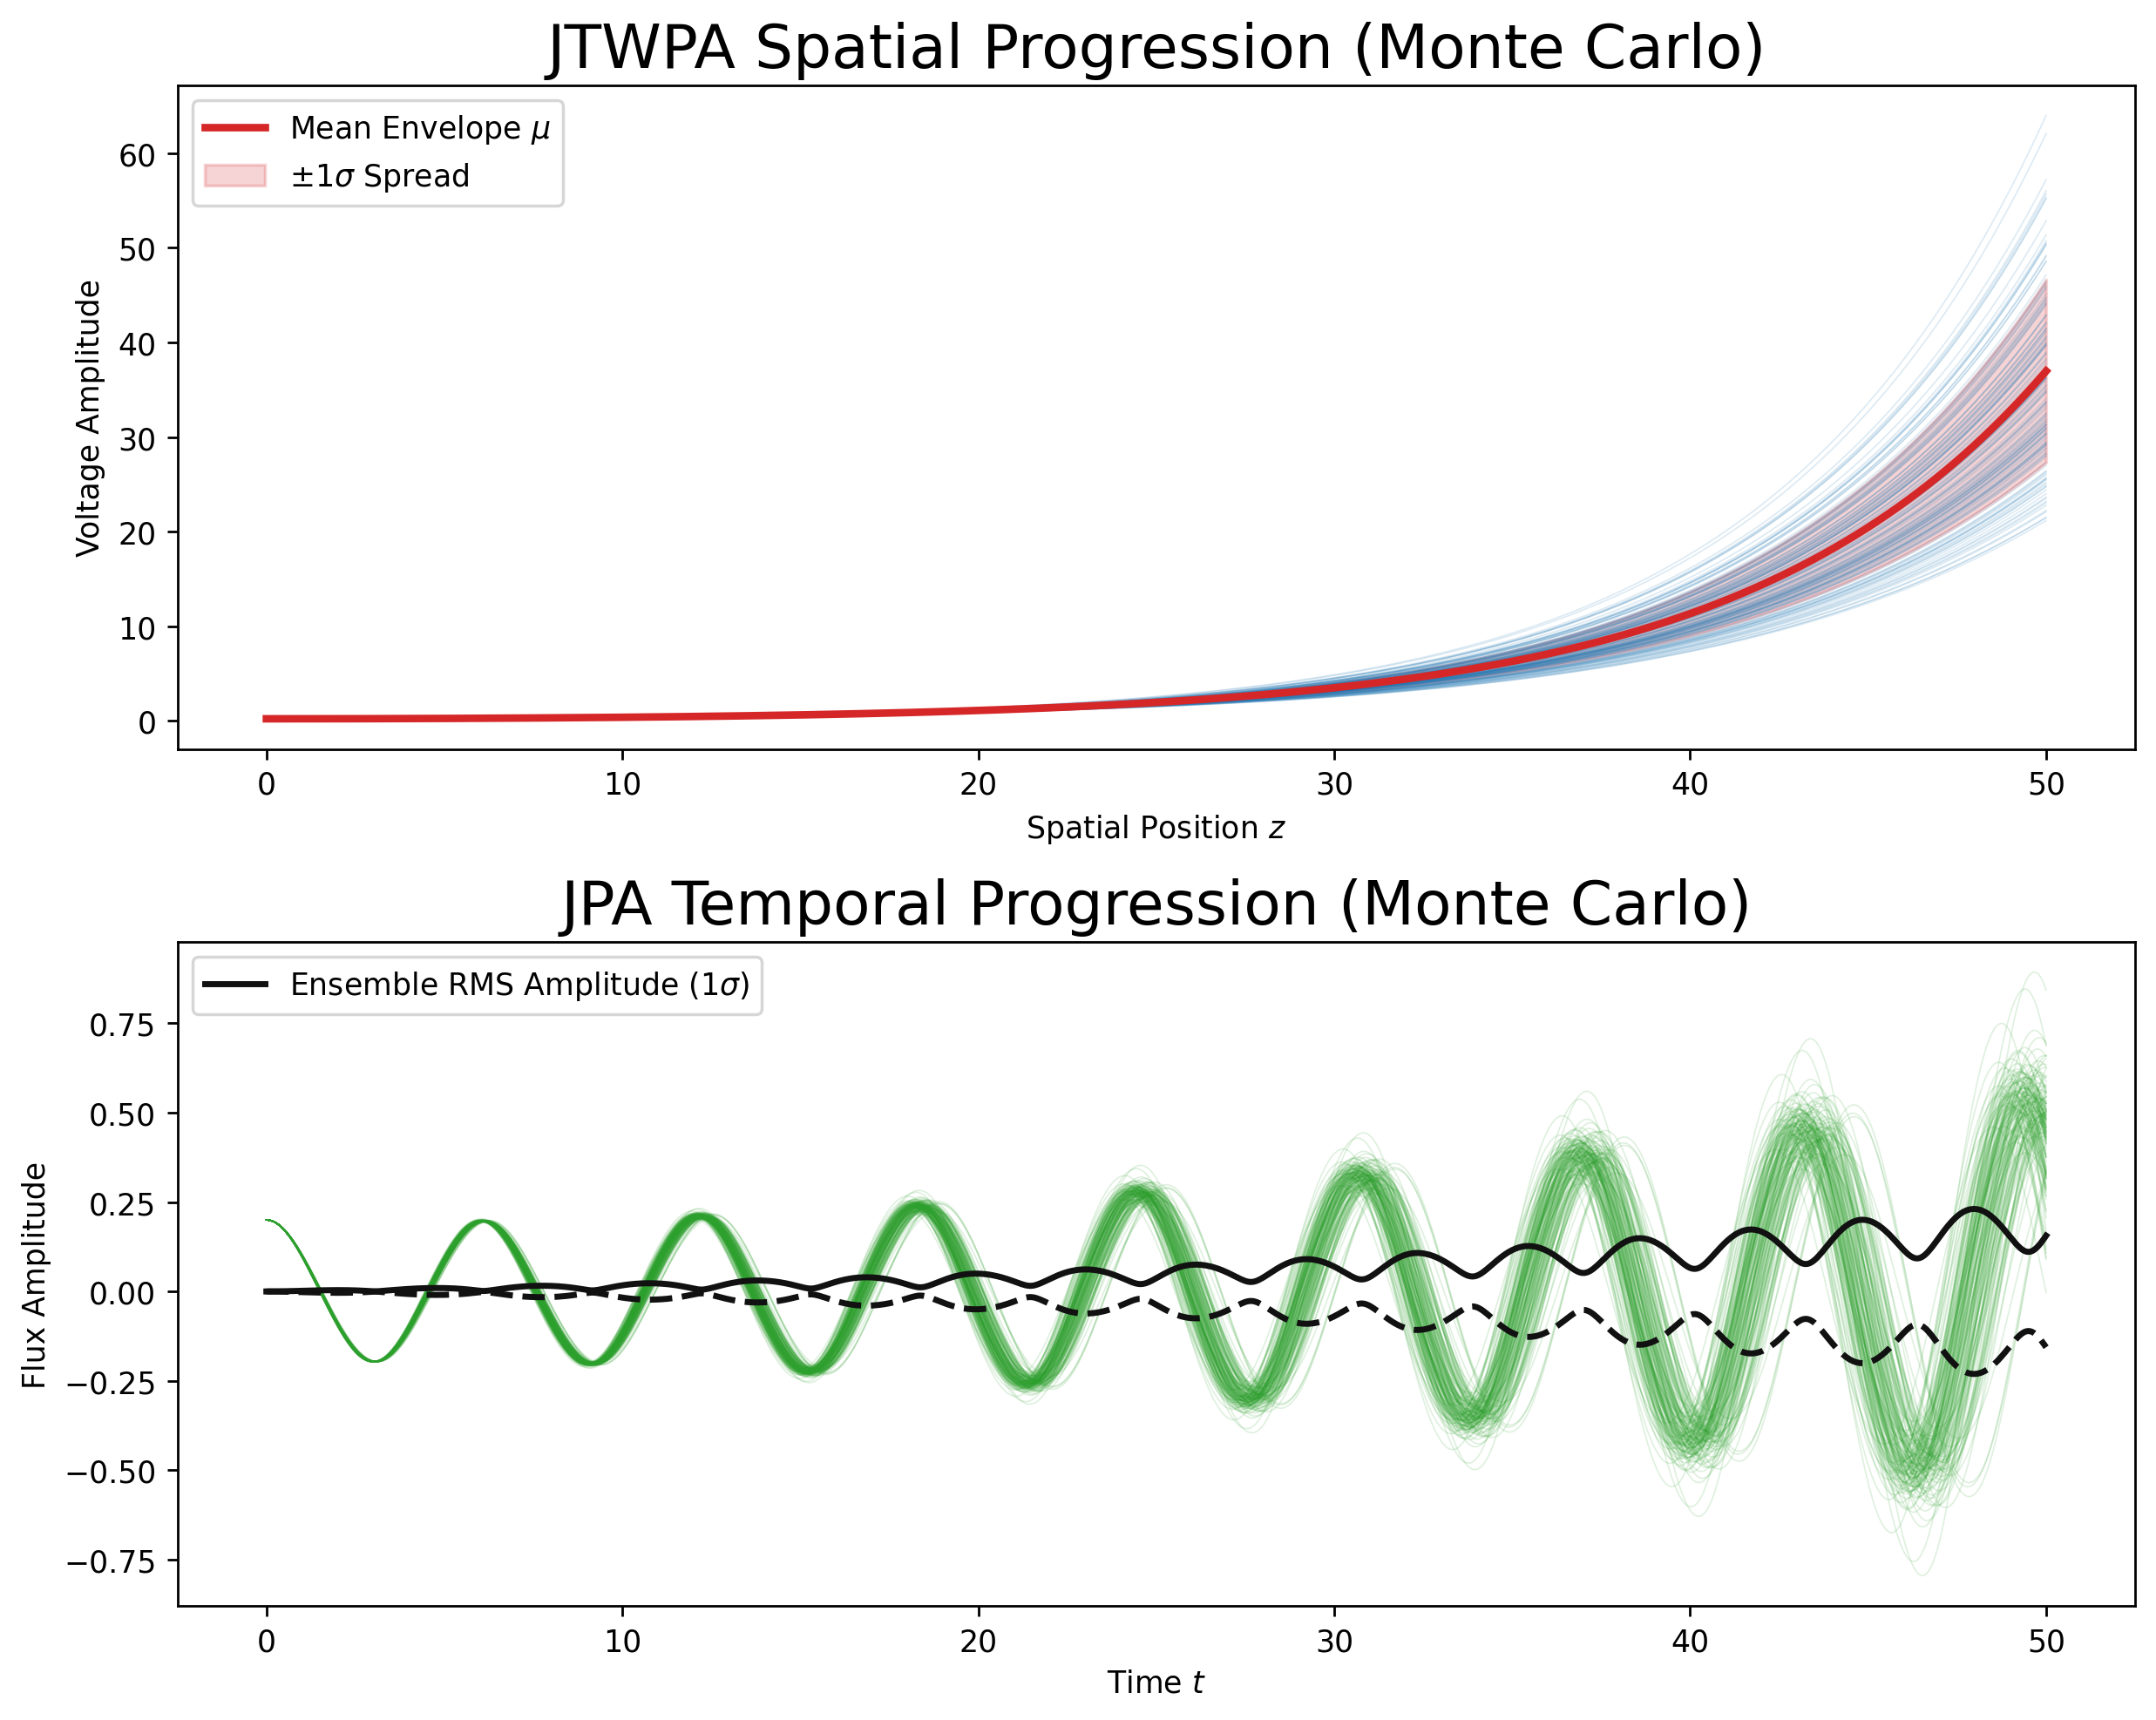

In [6]:
# Installation of necessary libraries via pip or uv
# pip install torch numpy scipy matplotlib
# uv pip install torch numpy scipy matplotlib

"""
GPU-Accelerated Monte Carlo Simulation of Superconducting Parametric Amplifiers.

This module executes a highly parallelized tensor integration of the Coupled Mode Theory (CMT)
spatial equations for a Josephson Traveling Wave Parametric Amplifier (JTWPA) and the
temporal Mathieu equation for a Josephson Parametric Amplifier (JPA) using PyTorch,
featuring corrected statistical envelope tracking.
"""

import torch
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# CONTROL KNOBS AND PARAMETERS
# =============================================================================
# Hardware Acceleration Selection
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Monte Carlo Statistical Parameters
MC_SAMPLES = 1000            # Number of parallel realizations
INTEGRATION_STEPS = 1000     # Granularity of the RK4 numerical solver

# JTWPA (Spatial Domain) Parameters
JTWPA_LENGTH = 50.0          # Total length of the transmission line
JTWPA_KAPPA_MEAN = 0.12      # Mean parametric coupling strength
JTWPA_KAPPA_STD = 0.005      # Variation in coupling strength (tightened)
JTWPA_DELTA_K_MEAN = 0.05    # Mean phase mismatch
JTWPA_DELTA_K_STD = 0.005    # Variation in phase mismatch (tightened)
JTWPA_SIGNAL_INIT = 0.2      # Initial signal amplitude
JTWPA_IDLER_INIT = 0.0       # Initial idler amplitude
JTWPA_WAVE_VECTOR = 2.0      # Spatial frequency for visualization

# JPA (Temporal Domain) Parameters
JPA_DURATION = 50.0          # Total duration of the pump pulse
JPA_OMEGA_0_MEAN = 1.0       # Mean cavity resonant frequency
JPA_OMEGA_0_STD = 0.01       # Variation in resonant frequency (tightened)
JPA_GAMMA = 0.02             # Cavity damping rate
JPA_LAMBDA_MEAN = 0.15       # Mean parametric modulation depth
JPA_LAMBDA_STD = 0.01        # Variation in modulation depth
JPA_PHI_INIT = 0.2           # Initial flux amplitude
JPA_PHIDOT_INIT = 0.0        # Initial flux derivative

# Matplotlib High-Resolution and Typography Settings
plt.rcParams.update({
    'figure.dpi': 250,
    'font.sans-serif': ['Tahoma', 'DejaVu Sans'],
    'font.weight': 'normal',
    'axes.titleweight': 'normal',
    'axes.titlesize': 20
})

# =============================================================================
# PARALLELIZED RUNGE-KUTTA 4 (RK4) INTEGRATOR
# =============================================================================
def compute_rk4_step(derivative_function, independent_var, dependent_vars, step_size, *args):
    """Execute a single vectorized fourth-order Runge-Kutta integration step."""
    k1 = derivative_function(independent_var, dependent_vars, *args)
    k2 = derivative_function(independent_var + step_size / 2.0, dependent_vars + k1 * (step_size / 2.0), *args)
    k3 = derivative_function(independent_var + step_size / 2.0, dependent_vars + k2 * (step_size / 2.0), *args)
    k4 = derivative_function(independent_var + step_size, dependent_vars + k3 * step_size, *args)
    return dependent_vars + (step_size / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)

# =============================================================================
# JTWPA MODEL SPATIAL COUPLED MODE THEORY ODEs (TENSORIZED)
# =============================================================================
def evaluate_jtwpa_tensor_derivatives(z, y, kappa, delta_k):
    """Evaluate the Coupled Mode Theory spatial derivatives across all Monte Carlo samples."""
    amplitude_s = y[0]
    amplitude_i_star = y[1]

    phase_term_neg = torch.exp(-1j * delta_k * z)
    phase_term_pos = torch.exp(1j * delta_k * z)

    derivative_s = 1j * kappa * amplitude_i_star * phase_term_neg
    derivative_i_star = -1j * kappa * amplitude_s * phase_term_pos
    return torch.stack([derivative_s, derivative_i_star])

jtwpa_kappa_dist = torch.normal(mean=JTWPA_KAPPA_MEAN, std=JTWPA_KAPPA_STD, size=(MC_SAMPLES,), device=DEVICE)
jtwpa_delta_k_dist = torch.normal(mean=JTWPA_DELTA_K_MEAN, std=JTWPA_DELTA_K_STD, size=(MC_SAMPLES,), device=DEVICE)

z_tensor_points = torch.linspace(0, JTWPA_LENGTH, INTEGRATION_STEPS, device=DEVICE)
z_step_size = JTWPA_LENGTH / (INTEGRATION_STEPS - 1)

jtwpa_state = torch.tensor([JTWPA_SIGNAL_INIT + 0j, JTWPA_IDLER_INIT + 0j], dtype=torch.complex64, device=DEVICE).unsqueeze(1).repeat(1, MC_SAMPLES)
jtwpa_history = torch.zeros((INTEGRATION_STEPS, MC_SAMPLES), dtype=torch.complex64, device=DEVICE)

for step_index, z_val in enumerate(z_tensor_points):
    jtwpa_history[step_index] = jtwpa_state[0]
    jtwpa_state = compute_rk4_step(evaluate_jtwpa_tensor_derivatives, z_val, jtwpa_state, z_step_size, jtwpa_kappa_dist, jtwpa_delta_k_dist)

jtwpa_z_cpu = z_tensor_points.cpu().numpy()
jtwpa_envelope_cpu = torch.abs(jtwpa_history).cpu().numpy()
jtwpa_mean_envelope = np.mean(jtwpa_envelope_cpu, axis=1)
jtwpa_std_envelope = np.std(jtwpa_envelope_cpu, axis=1)

# =============================================================================
# JPA MODEL TEMPORAL MATHIEU ODE (TENSORIZED)
# =============================================================================
def evaluate_jpa_tensor_derivatives(t, y, omega_0, gamma, lam):
    """Evaluate the temporal derivatives for the parametrically pumped oscillator across all samples."""
    flux = y[0]
    flux_derivative = y[1]

    derivative_flux = flux_derivative
    derivative_velocity = -gamma * flux_derivative - (omega_0**2) * (1.0 + lam * torch.cos(2.0 * omega_0 * t)) * flux
    return torch.stack([derivative_flux, derivative_velocity])

jpa_omega_0_dist = torch.normal(mean=JPA_OMEGA_0_MEAN, std=JPA_OMEGA_0_STD, size=(MC_SAMPLES,), device=DEVICE)
jpa_lambda_dist = torch.normal(mean=JPA_LAMBDA_MEAN, std=JPA_LAMBDA_STD, size=(MC_SAMPLES,), device=DEVICE)

t_tensor_points = torch.linspace(0, JPA_DURATION, INTEGRATION_STEPS, device=DEVICE)
t_step_size = JPA_DURATION / (INTEGRATION_STEPS - 1)

jpa_state = torch.tensor([JPA_PHI_INIT, JPA_PHIDOT_INIT], dtype=torch.float32, device=DEVICE).unsqueeze(1).repeat(1, MC_SAMPLES)
jpa_history = torch.zeros((INTEGRATION_STEPS, MC_SAMPLES), dtype=torch.float32, device=DEVICE)

for step_index, t_val in enumerate(t_tensor_points):
    jpa_history[step_index] = jpa_state[0]
    jpa_state = compute_rk4_step(evaluate_jpa_tensor_derivatives, t_val, jpa_state, t_step_size, jpa_omega_0_dist, JPA_GAMMA, jpa_lambda_dist)

jpa_t_cpu = t_tensor_points.cpu().numpy()
jpa_real_waveform_cpu = jpa_history.cpu().numpy()

# Calculate the statistical amplitude spread (standard deviation) to bypass phase cancellation
jpa_std_spread = np.std(jpa_real_waveform_cpu, axis=1)

# =============================================================================
# VISUALIZATION RENDERING
# =============================================================================
figure, (axis1, axis2) = plt.subplots(2, 1, figsize=(10, 8))
SUBSET_LIMIT = 150

# JTWPA Subplot
axis1.plot(jtwpa_z_cpu, jtwpa_envelope_cpu[:, :SUBSET_LIMIT], color='#1f77b4', linewidth=0.5, alpha=0.15)
axis1.plot(jtwpa_z_cpu, jtwpa_mean_envelope, color='#d62728', linewidth=2.5, label=r'Mean Envelope $\mu$')
axis1.fill_between(jtwpa_z_cpu, jtwpa_mean_envelope - jtwpa_std_envelope, jtwpa_mean_envelope + jtwpa_std_envelope, color='#d62728', alpha=0.2, label=r'$\pm 1\sigma$ Spread')
axis1.set_xlabel(r'Spatial Position $z$')
axis1.set_ylabel('Voltage Amplitude')
axis1.set_title('JTWPA Spatial Progression (Monte Carlo)')
axis1.legend(loc='upper left')
axis1.grid(False)

# JPA Subplot
axis2.plot(jpa_t_cpu, jpa_real_waveform_cpu[:, :SUBSET_LIMIT], color='#2ca02c', linewidth=0.5, alpha=0.15)
axis2.plot(jpa_t_cpu, jpa_std_spread, color='#111111', linewidth=2.0, label=r'Ensemble RMS Amplitude ($1\sigma$)')
axis2.plot(jpa_t_cpu, -jpa_std_spread, color='#111111', linewidth=2.0, linestyle='--')
axis2.set_xlabel(r'Time $t$')
axis2.set_ylabel('Flux Amplitude')
axis2.set_title('JPA Temporal Progression (Monte Carlo)')
axis2.legend(loc='upper left')
axis2.grid(False)

plt.tight_layout()
plt.show()